# Exploratory Data Analysis (EDA)
A fictitious datasets of a financial institution is given in the "data" folder.

The dataset called "Churn_clients" is composed by 10,000 rows and 14 columns of features, where one is the "Exited" column (target), composed by binary data: "1" if the client had left the bank, "0" if it had not.

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import shap
import xgboost as xgb
from tabpfn import TabPFNClassifier
from scipy.stats import chi2_contingency, pearsonr
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, roc_auc_score, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance
plt.rcParams.update({'font.size': 14})

In [2]:
df = pd.read_csv("data/Churn_clients.csv")

## Understanding the data structure

In the cells below, the data description shows that there are **5 numerical features** worth looking at: **Age, Balance, CreditScore, EstimatedSalary, and Tenure**.

The **Gender, Geography, NumOfProducts, IsActiveMember, HasCrCard, and Exited** are **categorical variables**, where the latter is the target.

In [3]:
df.shape         # Rows and columns
df.info()        # Data types, non-null counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


By observing the statistics further below, only the Geography feature has more than two categories, i.e., France, Spain, and Germany.

There are no duplicates or null values in this dataset.

In [4]:
df.head()        # Show first 5 rows

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
df['Geography'].unique()

array(['France', 'Spain', 'Germany'], dtype=object)

In [6]:
df['Gender'].unique()

array(['Female', 'Male'], dtype=object)

In [7]:
df.tail()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,10000,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


In [8]:
df.dtypes

RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

In [9]:
df.isnull().sum()         # Total missing per column

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

## Visualizing the data

We can get rid of a few columns, such as RowNumber, CustomerId, and Surname, because they have no utility in predicting the churn.

In [11]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


### Univariate analysis
Looking at the **Exited** variable, our target, approximately 20% of customers having churned. It is meaningful to this bank and the dataset is imbalanced.

Another imbalance we can see is in the **Geography**, where most customers are from *France*.

The **Gender** variable is balanced. The number of *male* and *female* customers is similar.

Analyzing **NumOfProducts**, the majority of customers have 1 or 2 products, very few have 3, and almost none have 4.

Most customers **have credit card**.

Pretty much half of the customers are **active**.

**Tenure** is uniformly distributed from 1 to 9, but there are much less customers with 0 and 10 years.

The **Age** is skewed to the right, i.e., fewer older customers.

Looking at the table at the beginning of this section and the plot below, **CreditScore** is centered around 650. There are a considerable amount of customers who have a lot of credit.

Most customers have 0 of **Balance**, but the rest of the customers are centered around 120k.

There are no relevant peaks or any relevant pattern to look at **EstimatedSalary**.

Thus, we can see the profile of the average customer here. Proceeding to a Bivariate Analysis can provide us more insights.

In [12]:
df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

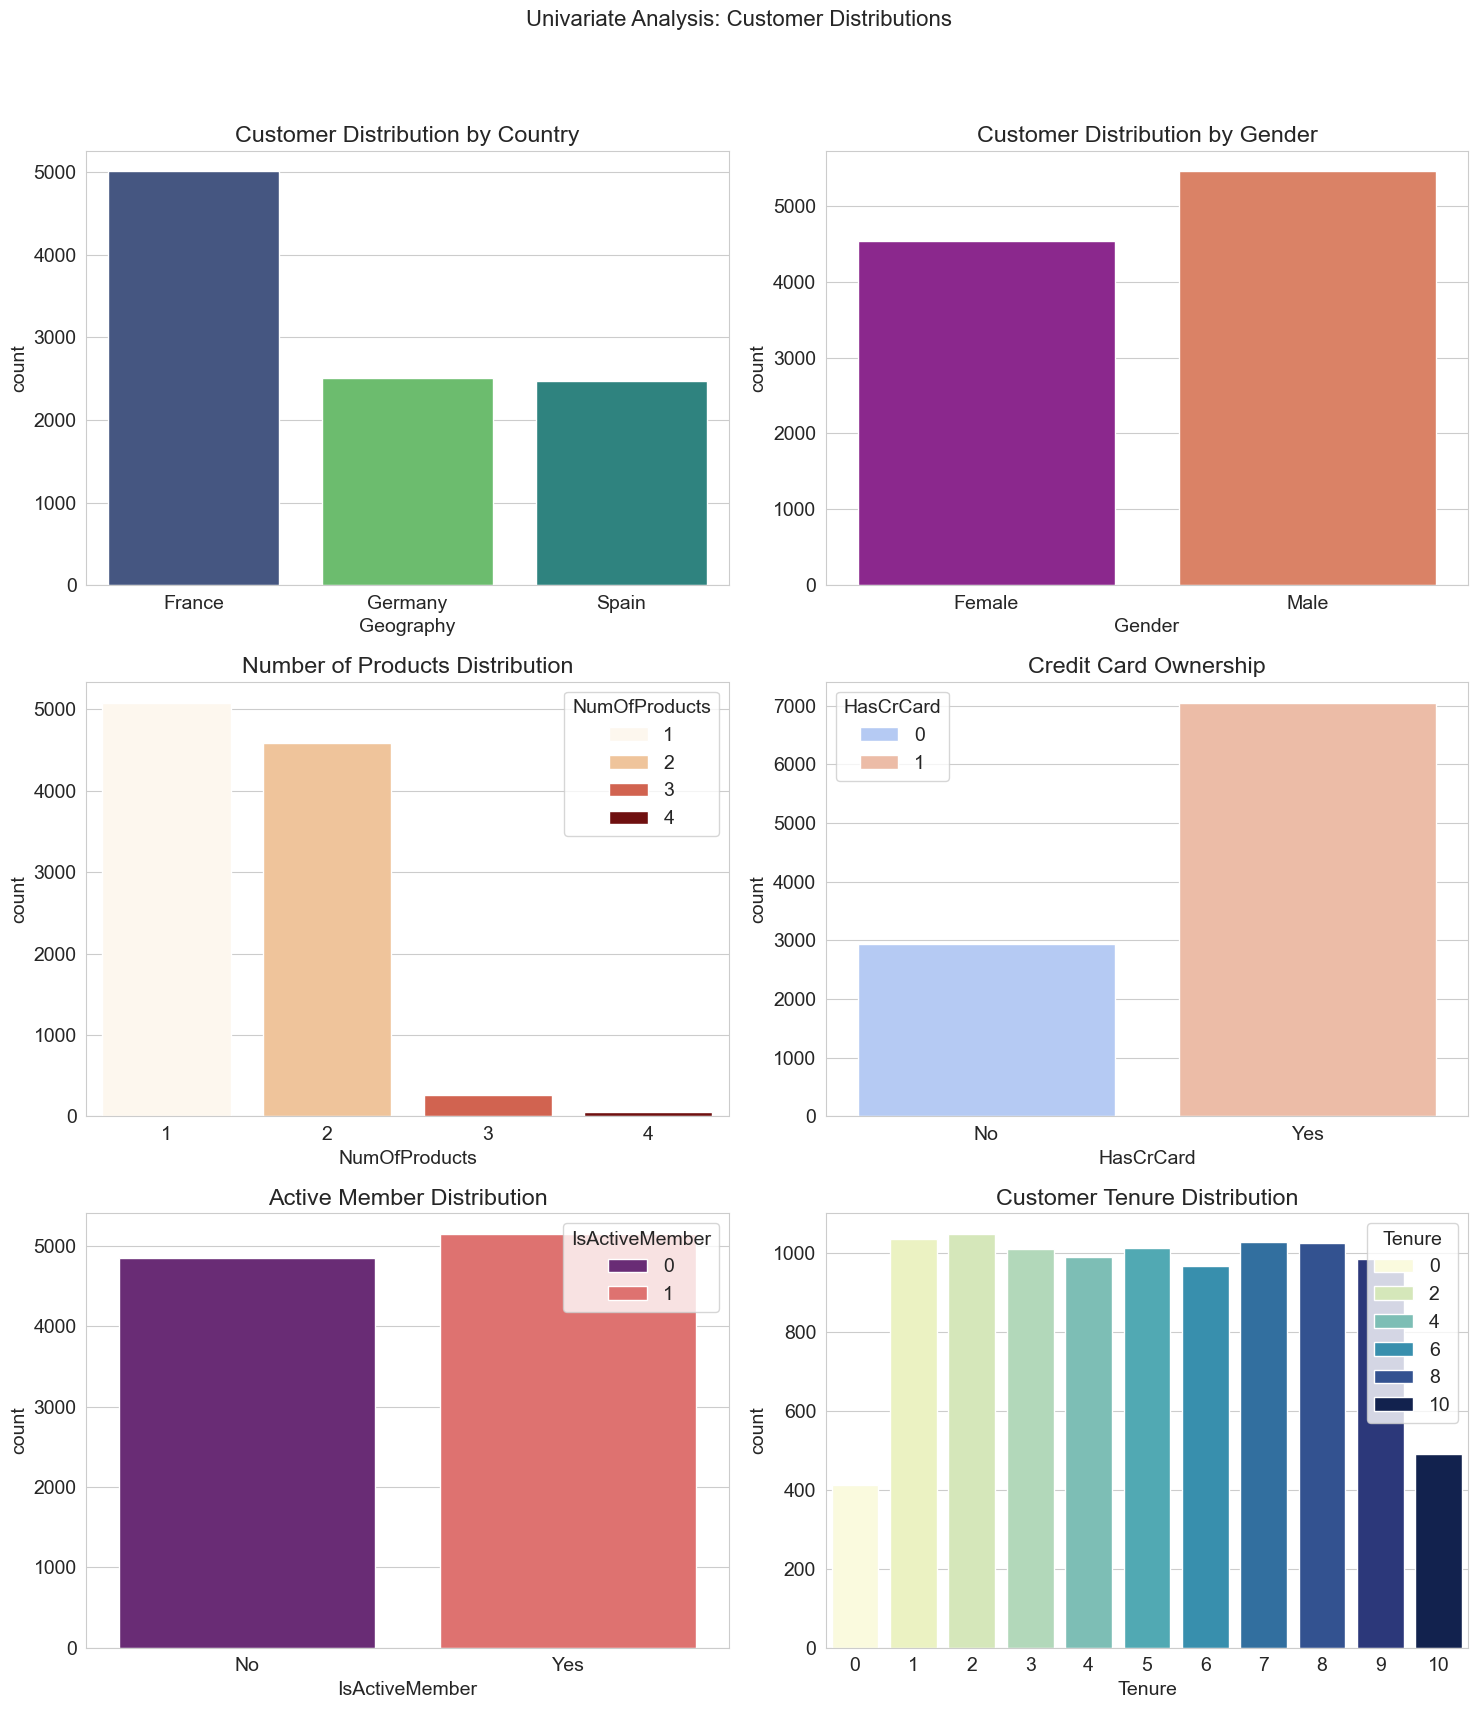

In [13]:
sns.set_style('whitegrid')

fig1, axes1 = plt.subplots(3, 2, figsize=(15, 18))
fig1.suptitle('Univariate Analysis: Customer Distributions', fontsize=16)

# Geography
sns.countplot(ax=axes1[0, 0], x='Geography', data=df, hue='Geography', palette='viridis', order=df['Geography'].value_counts().index)
axes1[0, 0].set_title('Customer Distribution by Country')

# Gender
sns.countplot(ax=axes1[0, 1], x='Gender', data=df, hue='Gender', palette='plasma')
axes1[0, 1].set_title('Customer Distribution by Gender')

# NumOfProducts
sns.countplot(ax=axes1[1, 0], x='NumOfProducts', data=df, hue='NumOfProducts', palette='OrRd')
axes1[1, 0].set_title('Number of Products Distribution')

# HasCrCard
sns.countplot(ax=axes1[1, 1], x='HasCrCard', data=df, hue='HasCrCard', palette='coolwarm')
axes1[1, 1].set_title('Credit Card Ownership')
axes1[1, 1].set_xticks([0, 1], ['No', 'Yes'])

# IsActiveMember
sns.countplot(ax=axes1[2, 0], x='IsActiveMember', data=df, hue='IsActiveMember', palette='magma')
axes1[2, 0].set_title('Active Member Distribution')
axes1[2, 0].set_xticks([0, 1], ['No', 'Yes'])

# Tenure
sns.countplot(ax=axes1[2, 1], x='Tenure', data=df, hue='Tenure', palette='YlGnBu')
axes1[2, 1].set_title('Customer Tenure Distribution')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

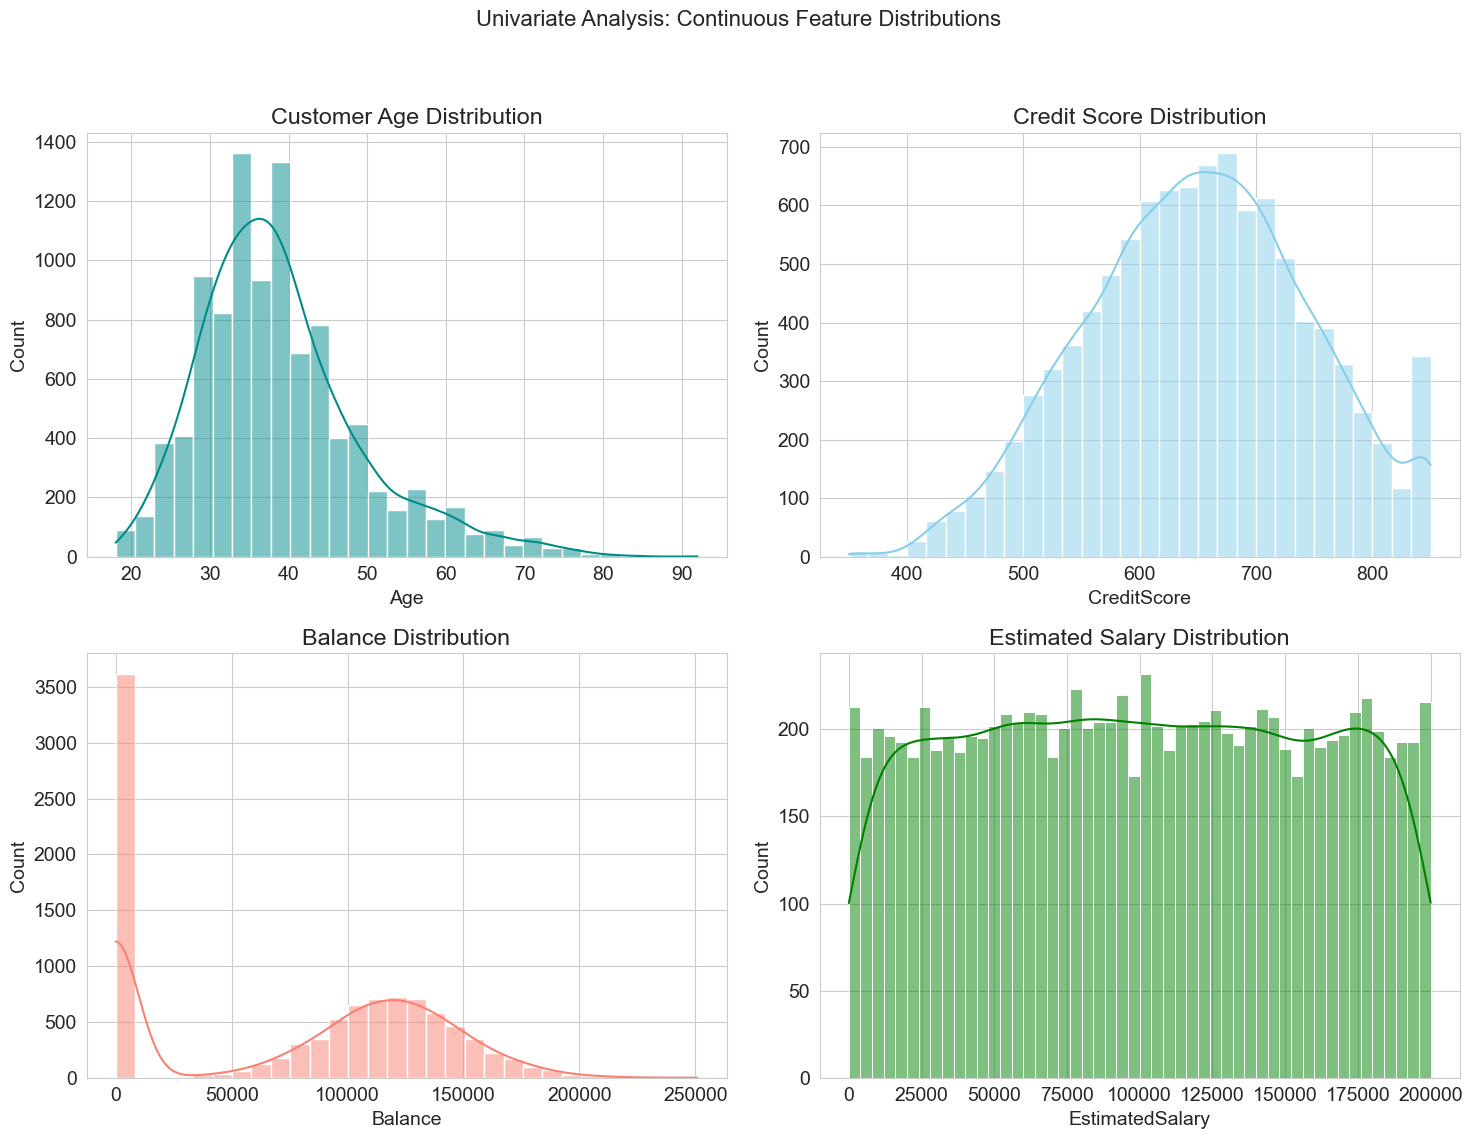

In [14]:
fig2, axes2 = plt.subplots(2, 2, figsize=(15, 12))
fig2.suptitle('Univariate Analysis: Continuous Feature Distributions', fontsize=16)

# Age
sns.histplot(ax=axes2[0, 0], data=df, x='Age', bins=30, kde=True, color='darkcyan')
axes2[0, 0].set_title('Customer Age Distribution')

# CreditScore
sns.histplot(ax=axes2[0, 1], data=df, x='CreditScore', bins=30, kde=True, color='skyblue')
axes2[0, 1].set_title('Credit Score Distribution')

# Balance
sns.histplot(ax=axes2[1, 0], data=df, x='Balance', bins=30, kde=True, color='salmon')
axes2[1, 0].set_title('Balance Distribution')

# EstimatedSalary
sns.histplot(ax=axes2[1, 1], data=df, x='EstimatedSalary', bins=50, kde=True, color='green')
axes2[1, 1].set_title('Estimated Salary Distribution')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Bivariate analysis

The plots below show that, although there are more customers in France, the highest proportion of people leaving the bank is at Germany.

Female customers are leaving more than male customers, even though there are less females.

The bank does not retain well the customers with 3 or 4 products. Most of them left. Maybe some products have a problem or they don't serve well customers who acquire more products.

As it is expected, the most likely to churn customers are inactive members.

Older customers have a higher tendency of leaving the bank.

The difference is very low, but people with lower credit scores might be a little more prone to churning.

Customers who have a higher balance are more likely to churn, looking at the median of the boxplots.

Looking at **Tenure**, **HasCrCard**, and **EstimatedSalary** variables in the plots below, there are no clear patterns.

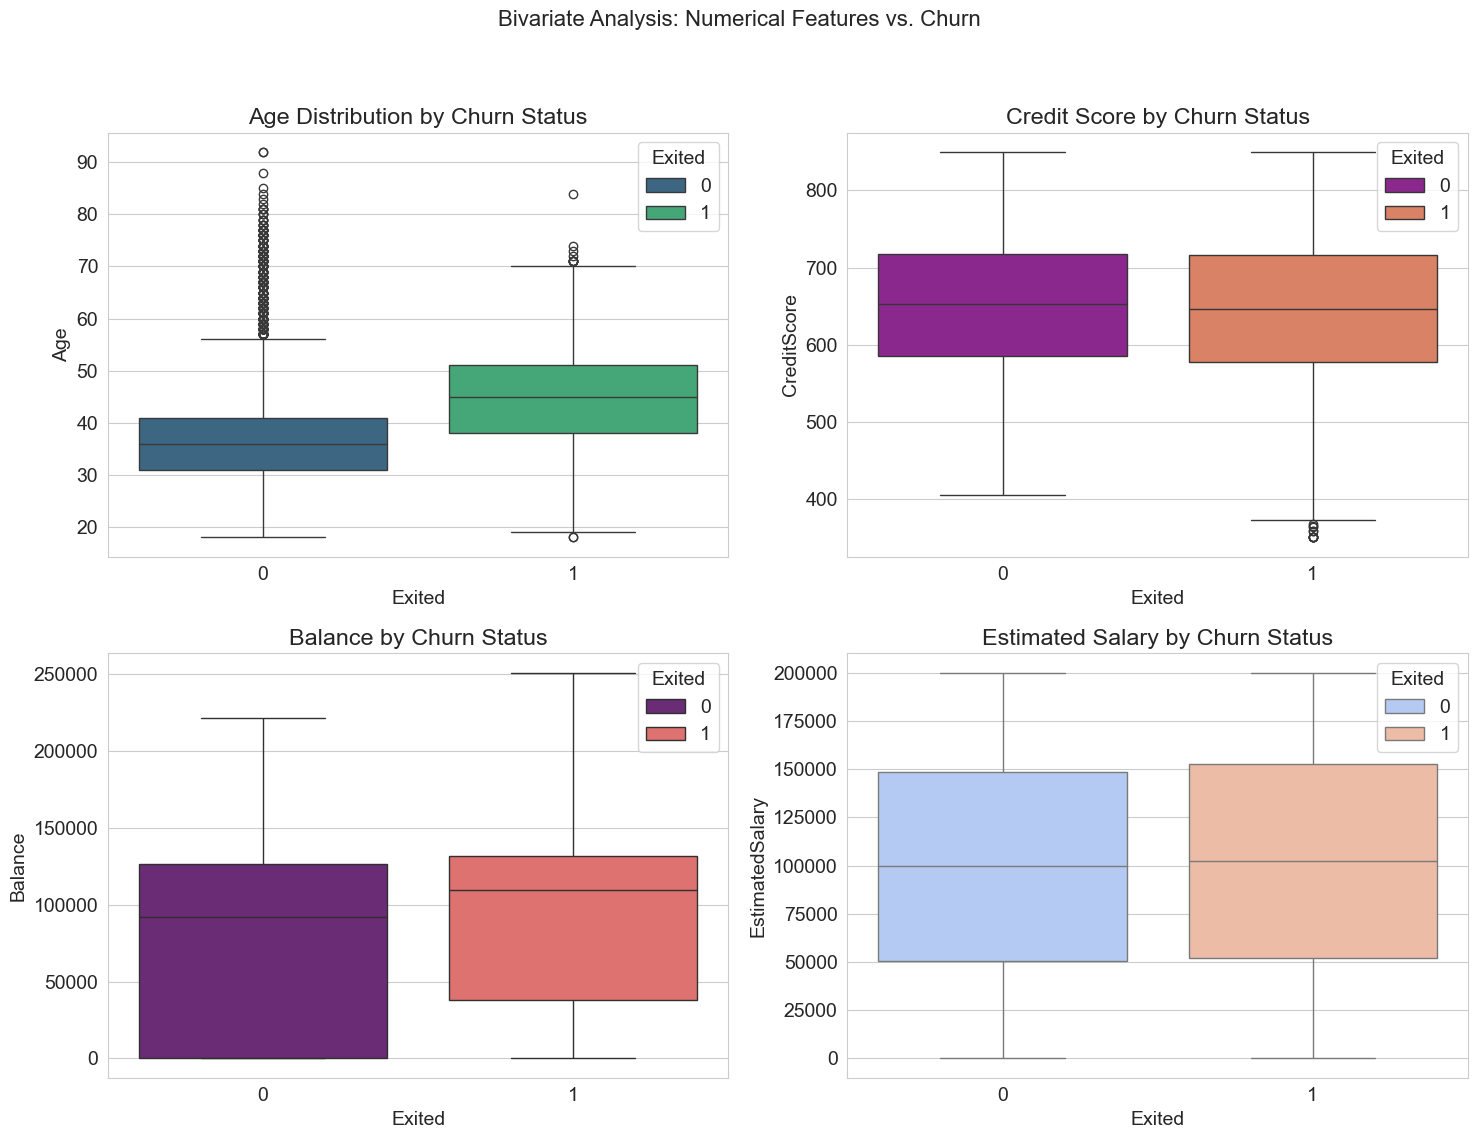

In [15]:
fig3, axes3 = plt.subplots(2, 2, figsize=(15, 12))
fig3.suptitle('Bivariate Analysis: Numerical Features vs. Churn', fontsize=16)

# Age vs. Exited
sns.boxplot(ax=axes3[0, 0], x='Exited', y='Age', data=df, hue='Exited', palette='viridis')
axes3[0, 0].set_title('Age Distribution by Churn Status')

# CreditScore vs. Exited
sns.boxplot(ax=axes3[0, 1], x='Exited', y='CreditScore', data=df, hue='Exited', palette='plasma')
axes3[0, 1].set_title('Credit Score by Churn Status')

# Balance vs. Exited
sns.boxplot(ax=axes3[1, 0], x='Exited', y='Balance', data=df, hue='Exited', palette='magma')
axes3[1, 0].set_title('Balance by Churn Status')

# EstimatedSalary vs. Exited
sns.boxplot(ax=axes3[1, 1], x='Exited', y='EstimatedSalary', data=df, hue='Exited', palette='coolwarm')
axes3[1, 1].set_title('Estimated Salary by Churn Status')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

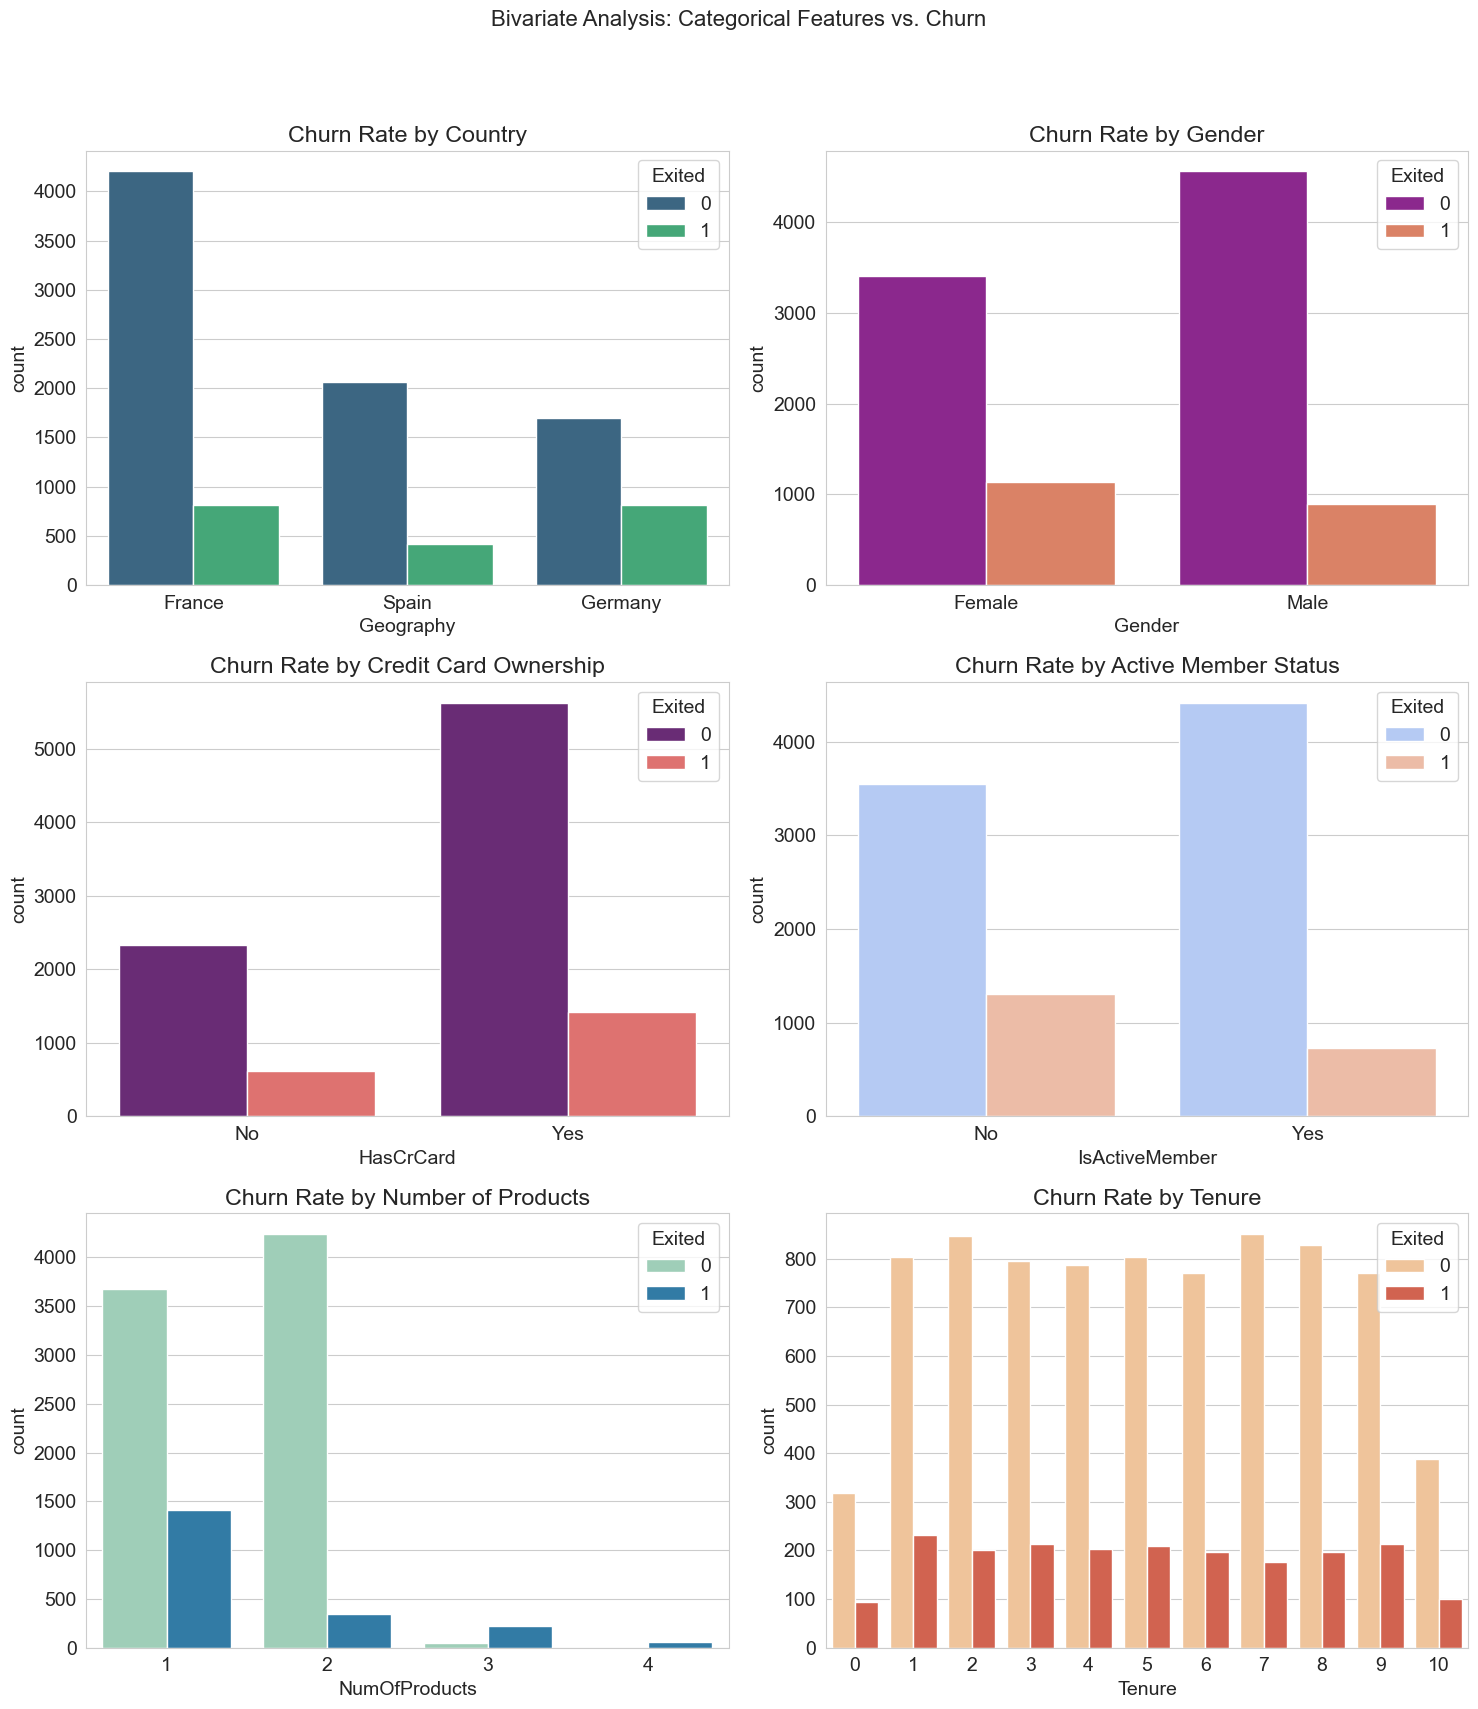

In [16]:
fig4, axes4 = plt.subplots(3, 2, figsize=(15, 18))
fig4.suptitle('Bivariate Analysis: Categorical Features vs. Churn', fontsize=16)

# Geography vs. Exited
sns.countplot(ax=axes4[0, 0], x='Geography', hue='Exited', data=df, palette='viridis')
axes4[0, 0].set_title('Churn Rate by Country')

# Gender vs. Exited
sns.countplot(ax=axes4[0, 1], x='Gender', hue='Exited', data=df, palette='plasma')
axes4[0, 1].set_title('Churn Rate by Gender')

# HasCrCard vs. Exited
sns.countplot(ax=axes4[1, 0], x='HasCrCard', hue='Exited', data=df, palette='magma')
axes4[1, 0].set_title('Churn Rate by Credit Card Ownership')
axes4[1, 0].set_xticks([0, 1], ['No', 'Yes'])

# IsActiveMember vs. Exited
sns.countplot(ax=axes4[1, 1], x='IsActiveMember', hue='Exited', data=df, palette='coolwarm')
axes4[1, 1].set_title('Churn Rate by Active Member Status')
axes4[1, 1].set_xticks([0, 1], ['No', 'Yes'])

# NumOfProducts vs. Exited
sns.countplot(ax=axes4[2, 0], x='NumOfProducts', hue='Exited', data=df, palette='YlGnBu')
axes4[2, 0].set_title('Churn Rate by Number of Products')

# Tenure vs. Exited
sns.countplot(ax=axes4[2, 1], x='Tenure', hue='Exited', data=df, palette='OrRd')
axes4[2, 1].set_title('Churn Rate by Tenure')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Chi-Square test for categorical features vs. churn
Check if there is statistically significant association between the categorical features and Exited.

In [17]:
categorical_cols = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember', 'NumOfProducts']

for cat in categorical_cols:
    print(f"----- Analysis for: {cat} -----")
    # Create a contingency table
    contingency = pd.crosstab(df[cat], df['Exited'])

    # Run chi-square test
    chi2, p_val, dof, expected = chi2_contingency(contingency)

    print(f"Chi-square statistic: {chi2:.4f}")
    print(f"p-value: {p_val:.4f}")
    print(f"Degrees of freedom: {dof}")

    # Interpretation
    if p_val < 0.05:
        print(f"Significant association exists between {cat} and Exited \n")
    else:
        print(f"No significant association between {cat} and Exited \n")

----- Analysis for: Geography -----
Chi-square statistic: 301.2553
p-value: 0.0000
Degrees of freedom: 2
Significant association exists between Geography and Exited 

----- Analysis for: Gender -----
Chi-square statistic: 112.9186
p-value: 0.0000
Degrees of freedom: 1
Significant association exists between Gender and Exited 

----- Analysis for: HasCrCard -----
Chi-square statistic: 0.4713
p-value: 0.4924
Degrees of freedom: 1
No significant association between HasCrCard and Exited 

----- Analysis for: IsActiveMember -----
Chi-square statistic: 242.9853
p-value: 0.0000
Degrees of freedom: 1
Significant association exists between IsActiveMember and Exited 

----- Analysis for: NumOfProducts -----
Chi-square statistic: 1503.6294
p-value: 0.0000
Degrees of freedom: 3
Significant association exists between NumOfProducts and Exited 



### Pearson correlation for numerical features vs. churn
Test to quantify the linear relationship between numerical features and churn.

----- Analysis for: CreditScore -----
Pearson's r: -0.0271
p-value: 0.0067
Significant negative correlation (r = -0.03) between CreditScore and Exited



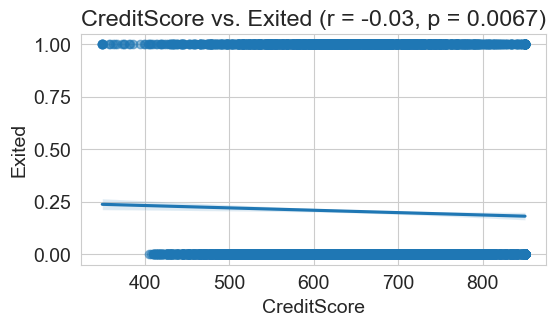

----- Analysis for: Age -----
Pearson's r: 0.2853
p-value: 0.0000
Significant positive correlation (r = 0.29) between Age and Exited



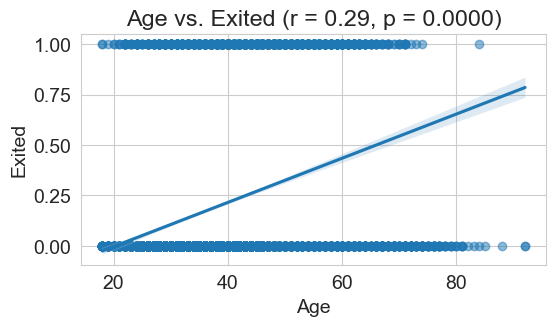

----- Analysis for: Tenure -----
Pearson's r: -0.0140
p-value: 0.1615
No significant correlation between Tenure and Exited



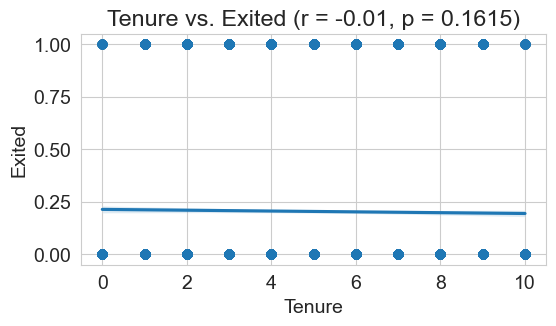

----- Analysis for: Balance -----
Pearson's r: 0.1185
p-value: 0.0000
Significant positive correlation (r = 0.12) between Balance and Exited



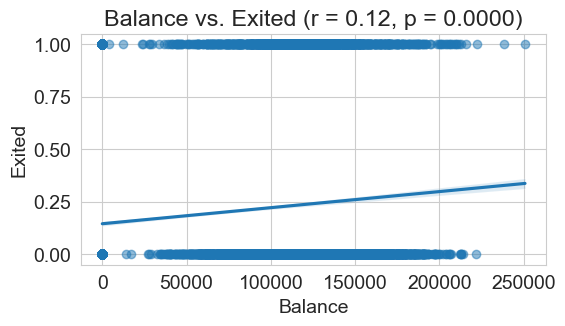

----- Analysis for: EstimatedSalary -----
Pearson's r: 0.0121
p-value: 0.2264
No significant correlation between EstimatedSalary and Exited



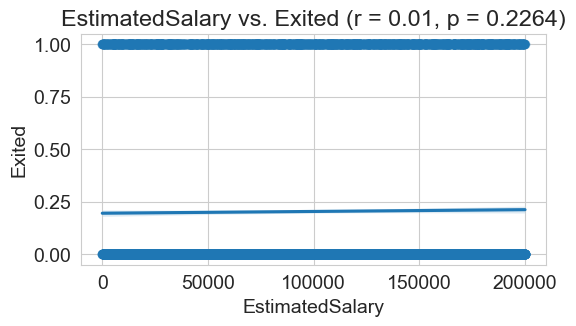

In [18]:
numerical_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']

for cat in numerical_cols:
    print(f"----- Analysis for: {cat} -----")
    # Calculate Pearson correlation
    r, p_val = pearsonr(df[cat], df['Exited'])
    
    print(f"Pearson's r: {r:.4f}")
    print(f"p-value: {p_val:.4f}")
    
    if p_val < 0.05:
        if r > 0:
            print(f"Significant positive correlation (r = {r:.2f}) between {cat} and Exited")
        else:
            print(f"Significant negative correlation (r = {r:.2f}) between {cat} and Exited")
    else:
        print(f"No significant correlation between {cat} and Exited")
    print('')

    # Visualize with scatter plot and regression line
    plt.figure(figsize=(6, 3))
    sns.regplot(x=cat, y='Exited', data=df, scatter_kws={'alpha':0.5})
    plt.title(f'{cat} vs. Exited (r = {r:.2f}, p = {p_val:.4f})')
    plt.xlabel(cat)
    plt.ylabel('Exited')
    plt.grid(True)
    plt.show()

### Correlation matrix of numerical features

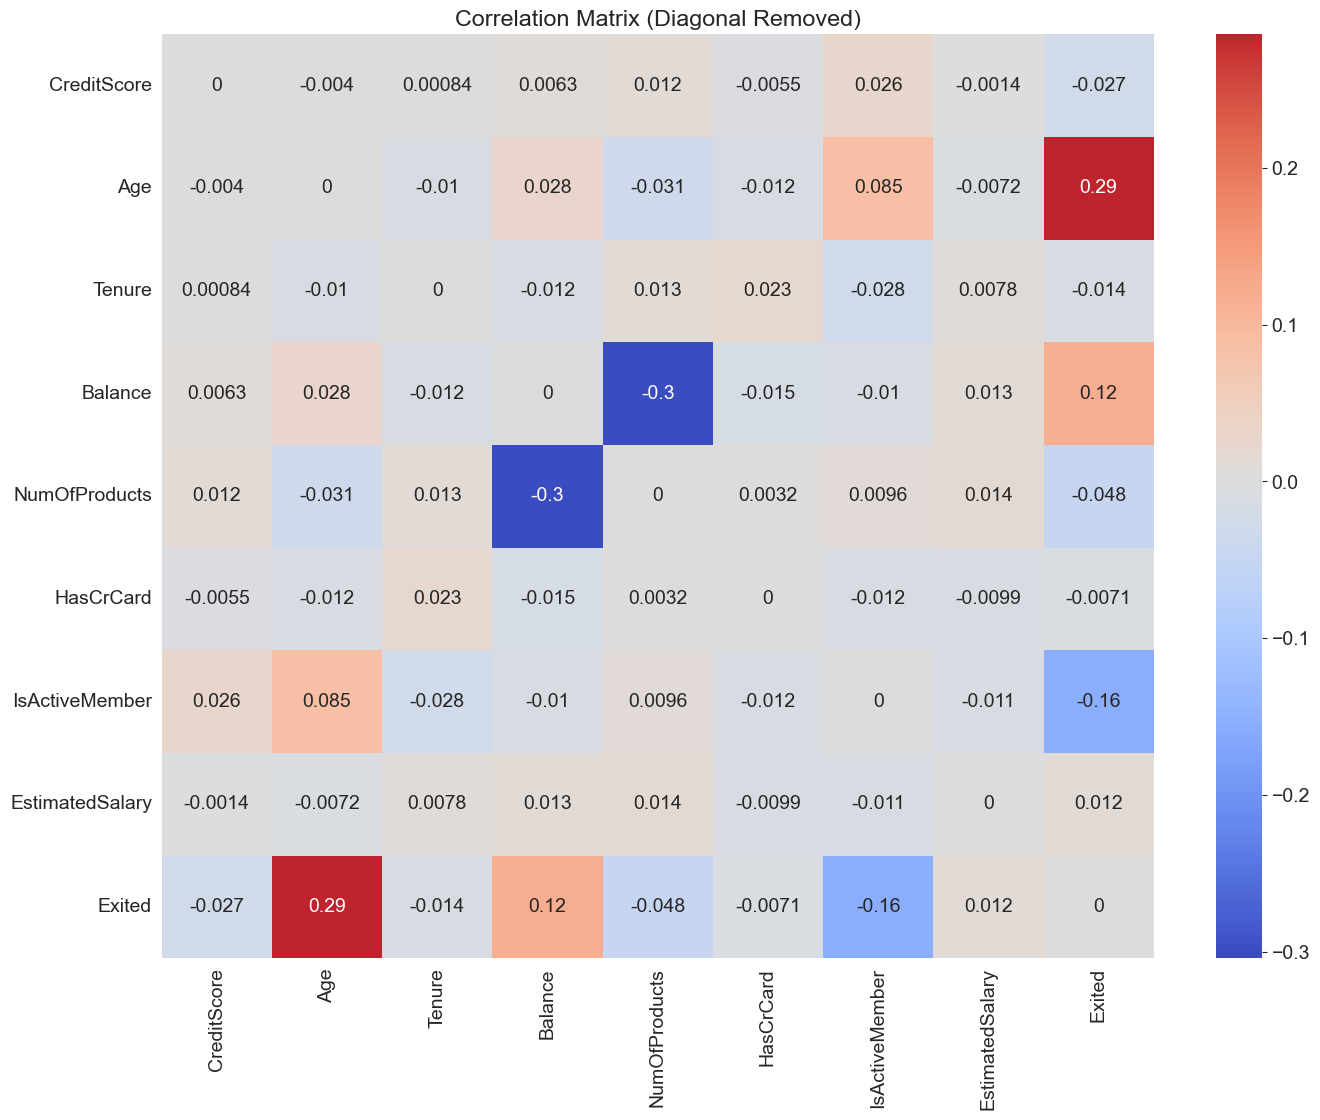

In [19]:
corr = df.corr(numeric_only=True)
np.fill_diagonal(corr.values, 0)  # removes diagonal
plt.figure(figsize=(16, 12))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix (Diagonal Removed)')
plt.show()

We can conclude that:
- **Geography**: people from *Germany* are more likely to churn;
- **Age**: Older people, around *45* years old (from $\approx$ *40* to *50* y.o.), have a higher churn rate;
- **Gender**: *Females* are leaving, both in proportion and quantity, more than males;
- **IsActive**: being *inactive* means that there is a higher chance of churning;
- **NumOfProducts**: having *3* or *4* products is a strong indicator of churn. Having *2* products seems to be the optimal for the bank; and
- **Balance**: zero balance customers are less likely to churn.

**CreditScore**, **Tenure**, **EstimatedSalary**, and **HasCreditCard** have little to no impact in the prediction of churn. Even though the p-value for **CreditScore** is less than 0.05, it is much higher than the other variables, indicating a weaker significance.

The correlation matrix shows the strongest relationship of Exited, which is with Age (0.29) and the weakest are with Tenure (-0.01) and EstimatedSalary (0.01).

Nonlinear relationships between these variables can be investigated to see how they are related. A predictor such as a deep neural network can model these relationships, or a feature engineering can be applied.

## Feature importance

#### Data preparation

In [20]:
df = pd.read_csv('data/Churn_clients.csv')

# Encode categorical variables
label_encoders = {}
for col in ['Geography', 'Gender']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Define features and target
X = df.drop(['RowNumber', 'CustomerId', 'Surname', 'Exited'], axis=1)
y = df['Exited']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

XGBoost Accuracy: 0.8555
XGBoost ROC AUC: 0.8475


<Figure size 1000x600 with 0 Axes>

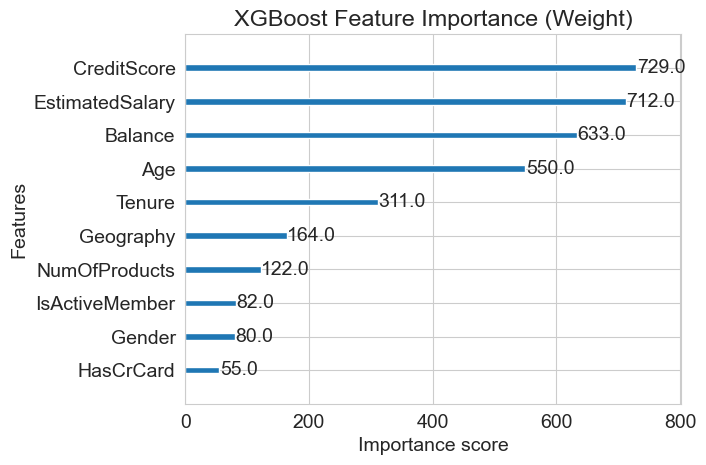

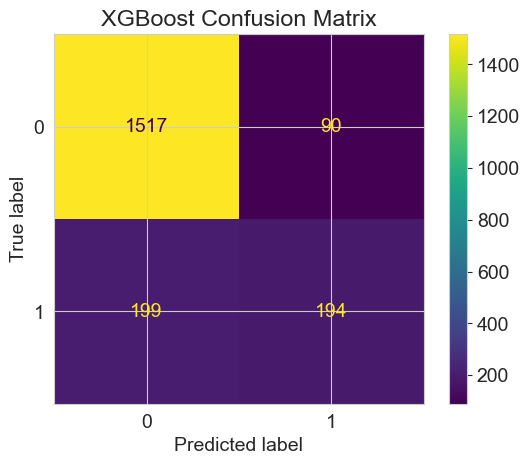


Feature importance:
NumOfProducts      34.201691
IsActiveMember     21.527048
Age                12.150749
Geography           7.213990
Balance             5.611351
Gender              5.136195
CreditScore         3.819623
EstimatedSalary     3.661088
Tenure              3.548646
HasCrCard           3.129622
dtype: float32


In [27]:
# Train XGBoost model
model = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print(f"XGBoost Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"XGBoost ROC AUC: {roc_auc_score(y_test, model.predict_proba(X_test)[:,1]):.4f}")

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title('XGBoost Confusion Matrix')
plt.show()

# Feature importance
top_features = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)*100
print("\nFeature importance:")
print(top_features)

c:\Users\gabri\AppData\Local\Programs\Python\Python313\Lib\site-packages\tabpfn\classifier.py:432: UserWarning: Running on CPU with more than 200 samples may be slow.
Consider using a GPU or the tabpfn-client API: https://github.com/PriorLabs/tabpfn-client
  check_cpu_warning(



TabPFN Accuracy: 0.8630
TabPFN ROC AUC: 0.8648


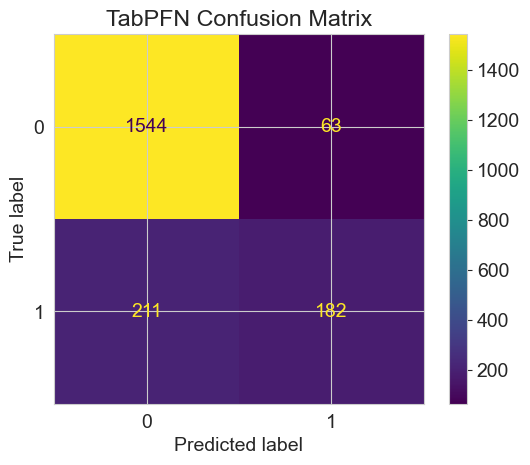

In [22]:
# Initialize TabPFN (works best with <1000 samples)
n_samples = min(1000, len(X_train))  # TabPFN limitation
X_train_tabpfn = X_train[:n_samples].values
y_train_tabpfn = y_train[:n_samples].values

# Train TabPFN
tabpfn = TabPFNClassifier(device='cpu')
tabpfn.fit(X_train_tabpfn, y_train_tabpfn)

# Evaluate
tabpfn_probs = tabpfn.predict_proba(X_test.values)[:, 1]
tabpfn_preds = (tabpfn_probs > 0.5).astype(int)
print(f"\nTabPFN Accuracy: {accuracy_score(y_test, tabpfn_preds):.4f}")
print(f"TabPFN ROC AUC: {roc_auc_score(y_test, tabpfn_probs):.4f}")

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, tabpfn_preds)
plt.title('TabPFN Confusion Matrix')
plt.show()

c:\Users\gabri\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but TabPFNClassifier was fitted without feature names
  warnings.warn(


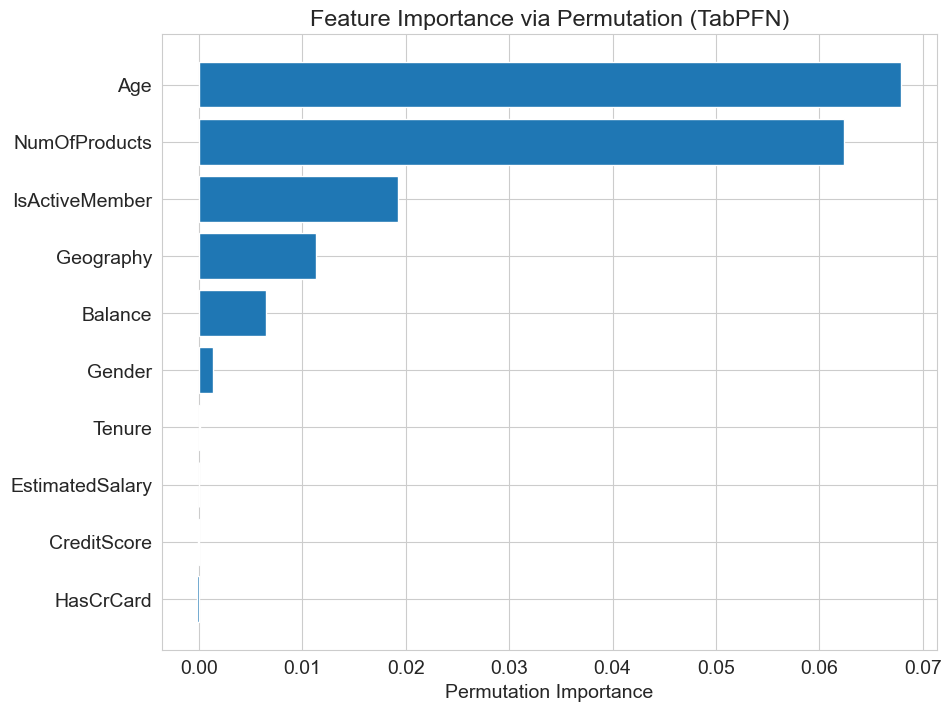

--- Top 5 Most Important Features ---
Age               0.06795
NumOfProducts     0.06235
IsActiveMember    0.01920
Geography         0.01135
Balance           0.00650
dtype: float64


In [ ]:
result = permutation_importance(
    tabpfn, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1
)

# --- Organize and Display Results ---
# Get the column names from your original feature DataFrame
feature_names = X.columns

# Create a pandas Series for easy sorting and plotting
perm_importance = pd.Series(result.importances_mean, index=feature_names).sort_values(ascending=True)

# --- Plot the Feature Importance ---
plt.figure(figsize=(10, 8))
plt.barh(perm_importance.index, perm_importance.values)
plt.xlabel("Permutation Importance")
plt.title("Feature Importance via Permutation (TabPFN)")
plt.show()

print("--- Top 5 Most Important Features ---")
print(perm_importance.sort_values(ascending=False).head())

In [29]:
# Compare model performances
results = pd.DataFrame({
    'Model': ['XGBoost', 'TabPFN'],
    'Accuracy': [accuracy_score(y_test, y_pred), accuracy_score(y_test, tabpfn_preds)],
    'ROC AUC': [roc_auc_score(y_test, model.predict_proba(X_test)[:,1]), roc_auc_score(y_test, tabpfn_probs)]
})

print("\nModel Comparison:")
print(results)


Model Comparison:
     Model  Accuracy   ROC AUC
0  XGBoost    0.8555  0.847498
1   TabPFN    0.8630  0.864839


c:\Users\gabri\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


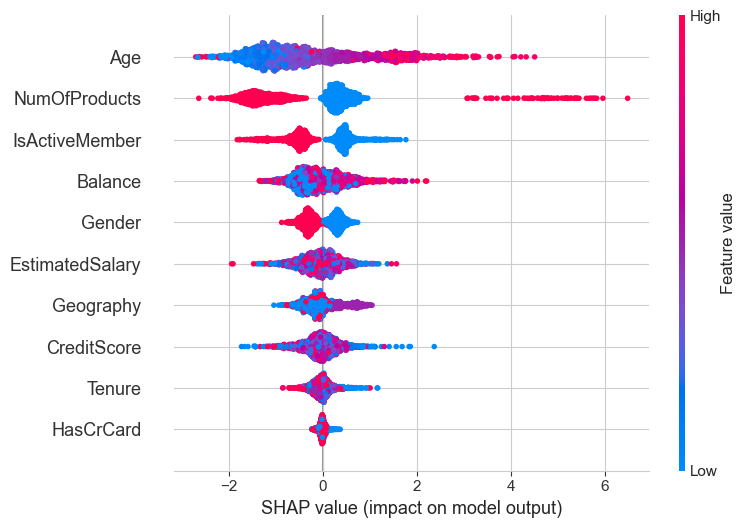

In [24]:
# SHAP values for detailed feature effects
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

## Conclusions:

TabPFN and XGBoost are showing the same conclusions about the importance of features as in the EDA performed.

- Older people are leaving;
- Churn is concentrated for 3, or 4 products;
- Inactive members tend to leave more;
- People with higher balance are leaving more;
- The churn is higher within females;
- Looking at Geography, Germans are leaving more;
- Estimated Salary alone is not very useful;
- Lower Credit Score show slightly higher churn, but it is not a very useful feature; and
- Tenure and Has Credit Card alone are not very useful features as well.